In [4]:
import s3fs
import pandas as pd



MY_BUCKET = "matheo"
CHEMIN_FICHIER = "diffusion/data/data_1995_2005.parquet"



fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER}") as f:
    df = pd.read_parquet(f)

In [6]:
display(df)

,time,rlat,rlon,lon,lat,fwi-daily-proj
0,2002-01-01,-23.375,-28.375,-10.063880,21.987829,1.0
1,2002-01-01,-23.375,-28.265,-9.963886,22.027838,1.0
2,2002-01-01,-23.375,-28.155,-9.863804,22.067716,1.0
3,2002-01-01,-23.375,-28.045,-9.763632,22.107462,1.0
4,2002-01-01,-23.375,-27.935,-9.663371,22.147077,1.0
...,...,...,...,...,...,...
701896379,1996-12-31,21.835,17.715,64.138911,66.937210,1.0
701896380,1996-12-31,21.835,17.825,64.346672,66.875684,1.0
701896381,1996-12-31,21.835,17.935,64.553500,66.813945,1.0
701896382,1996-12-31,21.835,18.045,64.759400,66.751995,1.0


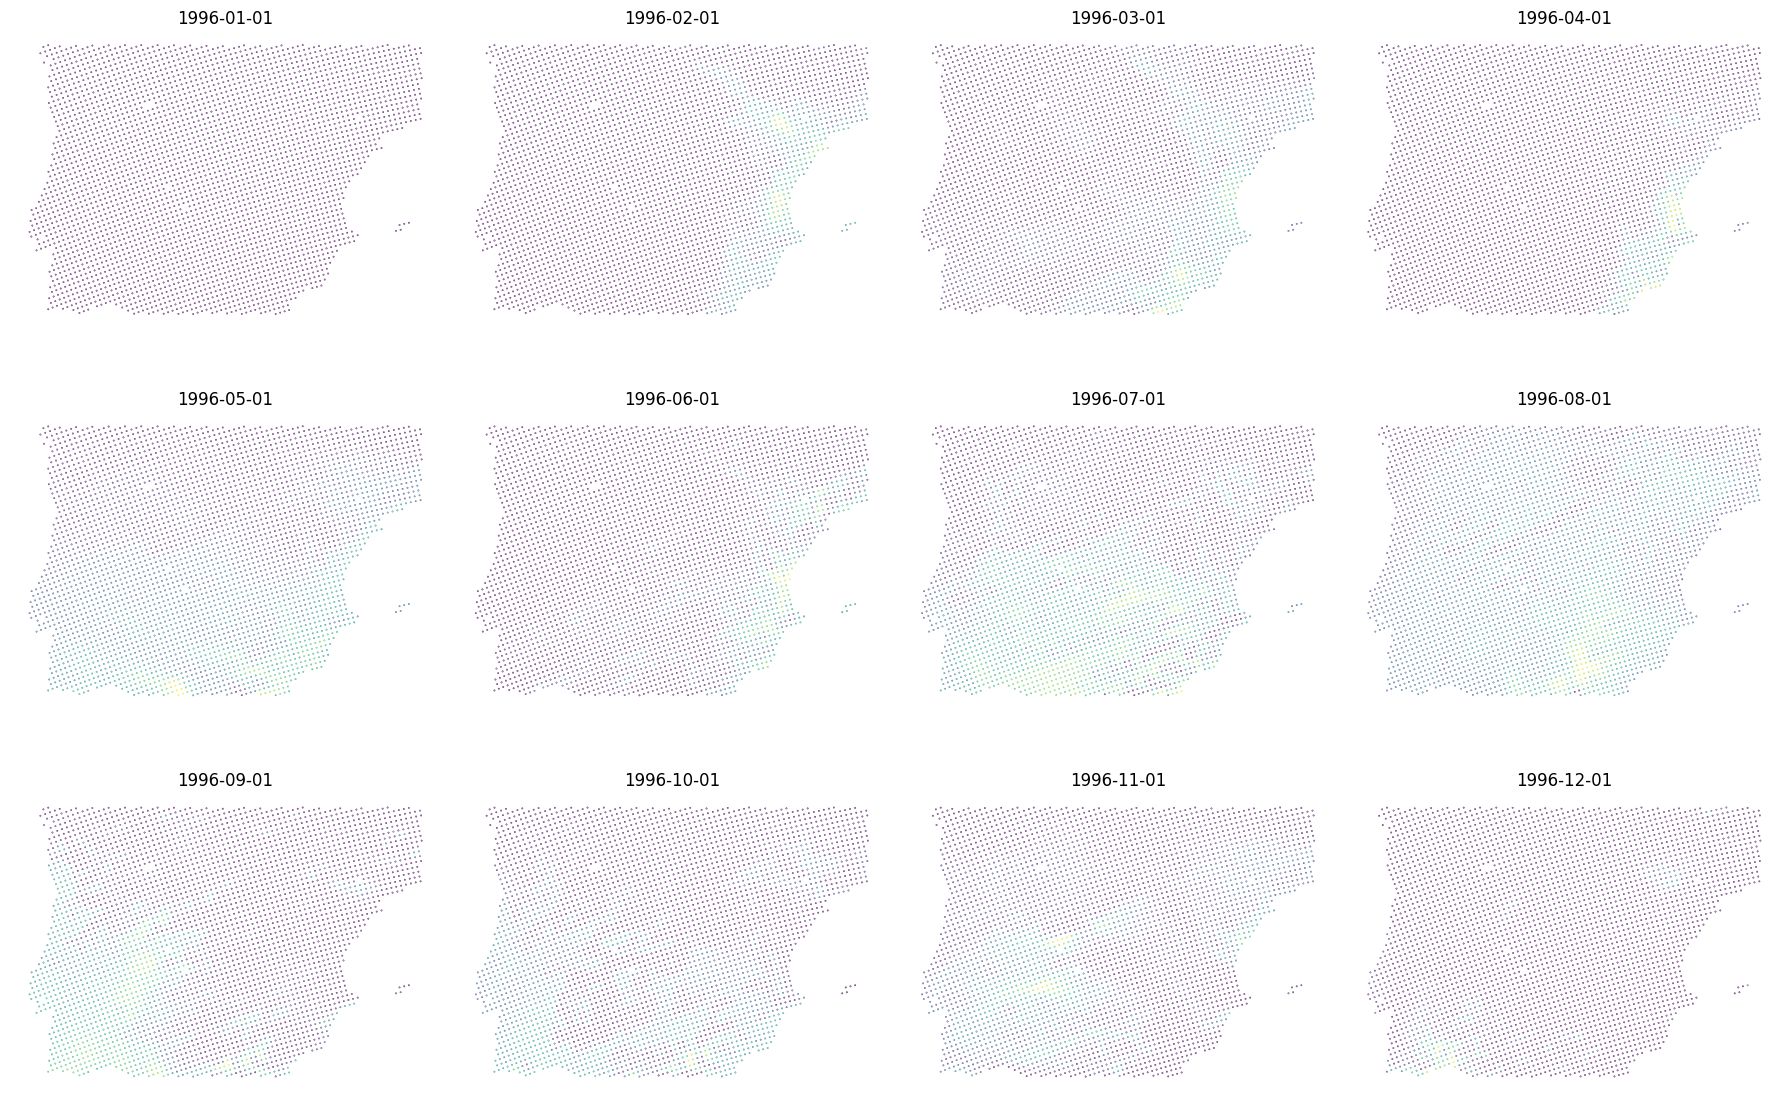

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt

#sélection de 12 cartes, une par mois
dates=['1996-01-01','1996-02-01','1996-03-01',
'1996-04-01','1996-05-01','1996-06-01',
'1996-07-01','1996-08-01','1996-09-01',
'1996-10-01','1996-11-01','1996-12-01']



fig, axes = plt.subplots(3, 4, figsize=(18,12))
axes = axes.flatten()

for i, date in enumerate(dates):
    
    temp = df[df["time"] == date].copy()
    temp = temp[(temp["lon"]>-10) & (temp["lon"]<2) & (temp["lat"]>37) & (temp["lat"]<43)]
    gdf = gpd.GeoDataFrame(
        temp,
        geometry=gpd.points_from_xy(temp["lon"], temp["lat"]),
        crs="EPSG:4326"
    )
    
    gdf.plot(
        ax=axes[i],
        column="fwi-daily-proj",
        markersize=0.1,
        legend=False
    )
    
    axes[i].set_title(date)
    axes[i].axis("off")

plt.tight_layout()
plt.show()